In [1]:
import torch
import pandas as pd
import glob
import numpy as np
import os.path
import tqdm
import matplotlib.pyplot as plt
import torch
from neml2.postprocessing import polefigure
import scipy.interpolate as inter
import scipy.optimize as opt

import neml2

import helpers, taylor

In [2]:
torch.set_default_dtype(torch.double)

In [3]:
# Inputs for deformation modeling
axial_index = 2
assumed_rate = 1.0e-4
d = torch.zeros((6,))
d[axial_index] = 1.0
# Number of data points for sampling the data
npoints = 500

In [24]:
get_stress = lambda s: float(os.path.basename(s).split(".")[0])
files = sorted(glob.glob('ff/*.csv'), key = get_stress)
stress_levels = [get_stress(f) for f in files]
data = [pd.read_csv(f) for f in files]
strain_stress = np.loadtxt('strain-stress.csv', delimiter = ',')

In [25]:
# Resample to reduce expense of simulating
ifn = inter.interp1d(strain_stress[:,0], strain_stress[:,1], kind = 'linear')
strain = np.linspace(0, strain_stress[-1,0], npoints)
stress = ifn(strain)
strain_stress = np.stack((strain, stress), axis = 1)

In [26]:
exp_strain = [helpers.load_strains(d) for d in data]
exp_texture = [helpers.load_orientations(d) for d in data]
exp_weights = [helpers.load_weights(d) for d in data]
avg_exp_strain = [torch.mean(ds, dim = 0) for ds in exp_strain]
avg_axial_strain = [s[axial_index] - avg_exp_strain[0][axial_index] for s in avg_exp_strain]
use_weights = exp_weights[0]

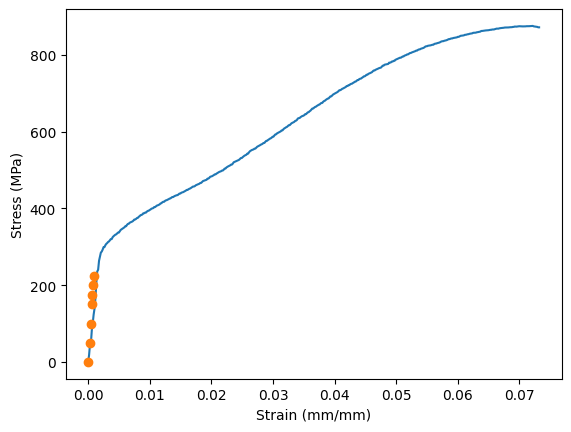

In [7]:
plt.figure()
plt.plot(strain_stress[:,0], strain_stress[:,1])
plt.plot(avg_axial_strain, stress_levels, 'o')
plt.xlabel('Strain (mm/mm)')
plt.ylabel("Stress (MPa)")
plt.show()

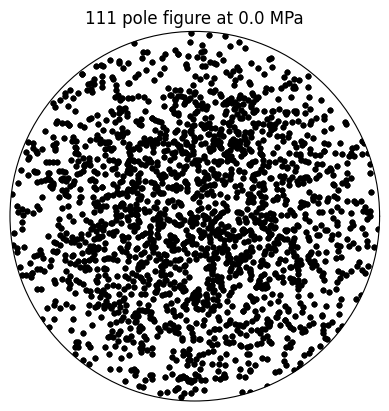

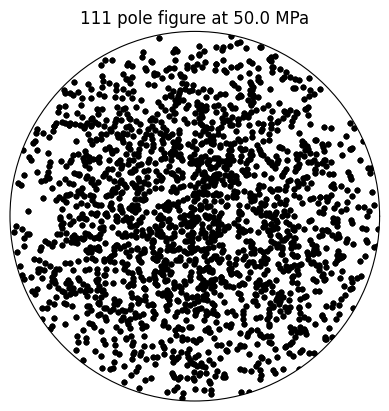

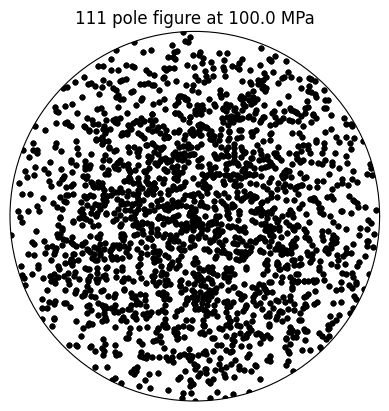

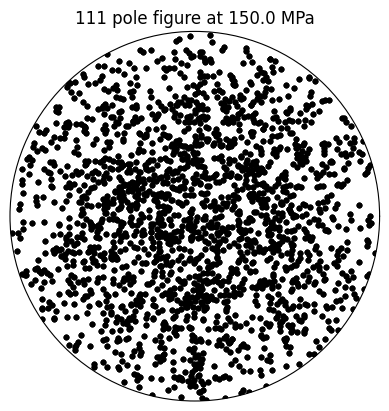

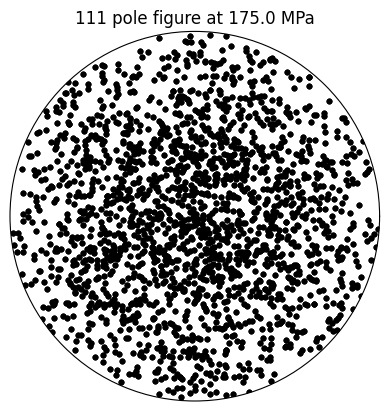

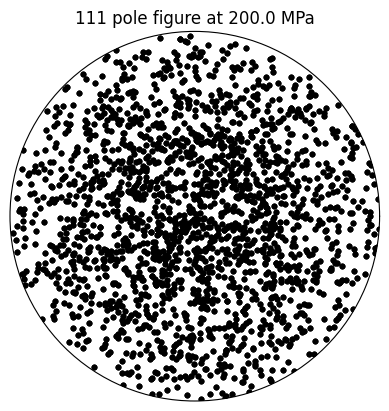

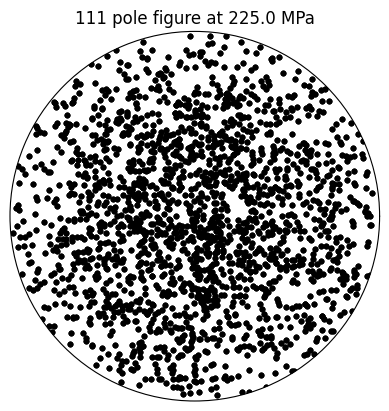

In [8]:
# Plot experimental texture
for stress, t in zip(stress_levels, exp_texture):
    polefigure.pretty_plot_pole_figure_points(t, torch.tensor([1.0, 1.0, 1.0]), crystal_symmetry = "432")
    plt.title(f'111 pole figure at {stress} MPa')
    plt.show()

In [9]:
# Setup model
model = neml2.load_model("models/template.i", "model_with_stress")
tmodel = taylor.UniaxialTaylorModel(model)

In [10]:
# List of values to optimize
# Ignore the rate sensitity and the gamma0 because we only have values at a single rate
opt_vars = ['elastic_tensor_E', 'elastic_tensor_G', 'elastic_tensor_nu', 'slip_strength_constant_strength', 'voce_hardening_initial_slope', 'voce_hardening_saturated_hardening']
p0 = torch.Tensor([tmodel.model.get_parameter(v).torch().detach().clone() for v in opt_vars])

In [11]:
# Simulate the stress-strain curve
def simulate_stress(p, return_state = False, initial_strains = None):
    with torch.no_grad():
        for v, pv in zip(opt_vars, p):
            tmodel.model.set_parameter(v, neml2.Tensor(pv, 0))
        old_state = tmodel.initial_state(exp_texture[0], elastic_strain=initial_strains)
        old_stress = torch.zeros(old_state.shape[0], 6)
        old_time = 0.0

        stress_hist = [torch.zeros((6,))]
        state_hist = [old_state.clone()]
        ds_guess = None
        de_guess = None
        for e0, e1 in zip(strain_stress[:-1, 0], strain_stress[1:, 0]):
            de = e1 - e0
            dt = de / assumed_rate

            avg_stress, old_stress, old_state, ds_guess, de_guess = tmodel(
                de, dt, d, old_state, old_time, old_stress, weights = use_weights, stress_inc_guess = ds_guess, e_inc_guess = de_guess
            )
            old_time = old_time + dt
            stress_hist.append(avg_stress)
            state_hist.append(old_state.clone())

    if return_state:
        return torch.stack(stress_hist, dim=0), torch.stack(state_hist, dim = 0)
    return torch.stack(stress_hist, dim=0)

Text(0.5, 1.0, 'Initial guess')

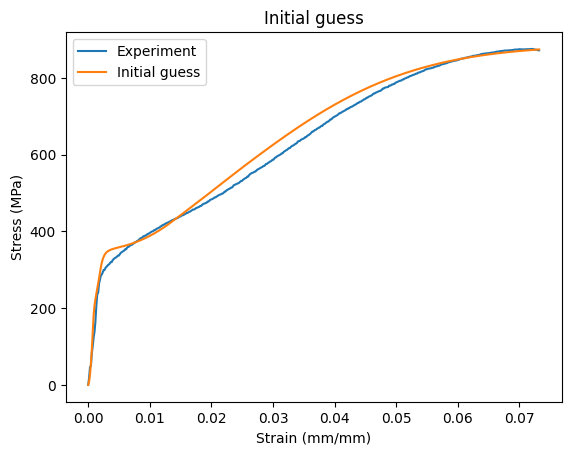

In [12]:
initial_stress, initial_state_hist = simulate_stress(p0, return_state = True)
initial_stress = initial_stress[:, axial_index].numpy()
plt.figure()
plt.plot(strain_stress[:,0], strain_stress[:,1], label = 'Experiment')
plt.plot(strain_stress[:,0], initial_stress, label = 'Initial guess')
plt.xlabel('Strain (mm/mm)')
plt.ylabel("Stress (MPa)")
plt.legend()
plt.title("Initial guess")

Text(0.5, 1.0, '111 pole figure at some arbitrary time')

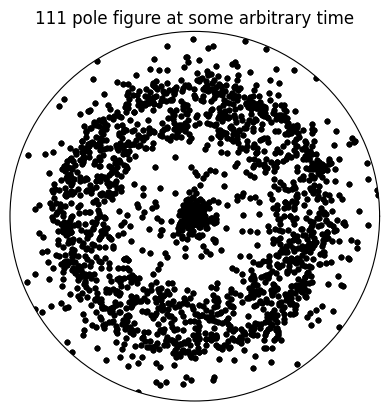

In [13]:
test_state = tmodel.state_asm.split_by_variable(neml2.Tensor(initial_state_hist,1))
polefigure.pretty_plot_pole_figure_points(test_state["state/orientation"].torch()[-400], torch.tensor([1.0, 1.0, 1.0]), crystal_symmetry = "432")
plt.title(f'111 pole figure at some arbitrary time')

Text(0.5, 1.0, 'Elastic strain distribution at some arbitrary time')

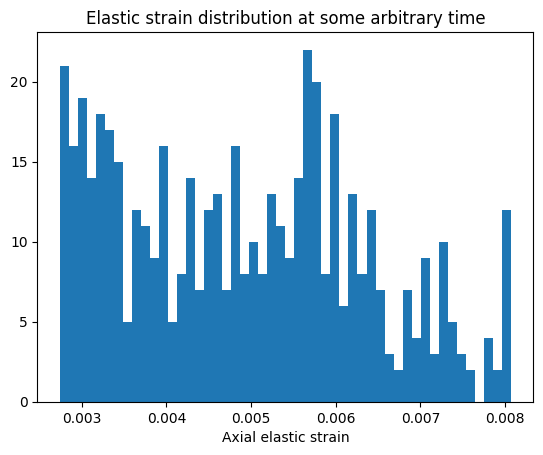

In [14]:
plt.hist(test_state["state/elastic_strain"].torch()[10,:,axial_index].numpy(), bins = 50)
plt.xlabel("Axial elastic strain")
plt.title("Elastic strain distribution at some arbitrary time")

In [15]:
def obj(p, default_err = 1e6):
    p = torch.tensor(p)
    try:
        sim_stress = simulate_stress(p)[:, axial_index]
    except Exception as e:
        return default_err
    err = sim_stress - torch.tensor(strain_stress[:,1])
    res = torch.norm(err).numpy()
    return res

In [16]:
optx = opt.minimize(obj, p0.numpy(), method = 'Nelder-Mead', options = {"maxiter": 50}).x
optx = torch.tensor(optx)
print(optx)
opt_stress = simulate_stress(optx)[:, axial_index].numpy()
plt.figure()
plt.plot(strain_stress[:,0], strain_stress[:,1], label = 'Experiment')
plt.plot(strain_stress[:,0], opt_stress, label = 'Optimized')
plt.xlabel('Strain (mm/mm)')
plt.ylabel("Stress (MPa)")
plt.legend()

KeyboardInterrupt: 

In [18]:
# Form a strain history with the measured point
new_strain = torch.sort(torch.cat([torch.tensor(strain), torch.tensor([e[axial_index] for e in avg_exp_strain])]))[0]
inds = [torch.argmin(torch.abs(new_strain - e[axial_index])).item() for e in avg_exp_strain]

In [19]:
stress_hist, state_hist = simulate_stress(optx, return_state = True)
vars = tmodel.state_asm.split_by_variable(neml2.Tensor(state_hist, 1))

0.0014669804852050787 9.48869591250755e-10
0.0004528730998129921 0.00014872807913392965
0.002944145028839852 0.0001539084639225739
0.000669992746279441 0.00017113938899979478
0.003983579846108068 0.0007862313929800684
0.0008534963114561752 0.00020662279683746963
0.005429330765619956 0.0017917564838010845
0.0010700642226195221 0.00021920314337110138
0.005982347632066279 0.002166532090510283
0.0011500610093379722 0.00021378047622255315
0.007115483911158796 0.0028384953407012002
0.0012377701541656685 0.0002085209312110813
0.00796748523129584 0.003156619662197541
0.0013482763301317364 0.00019791618318352615


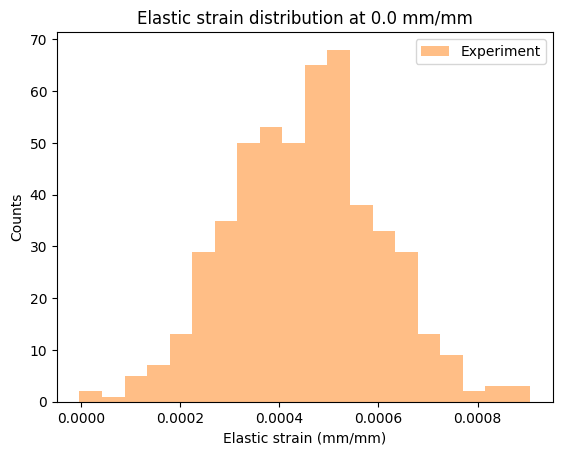

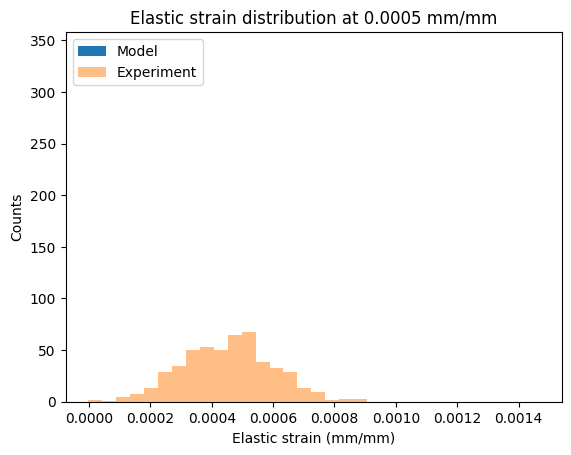

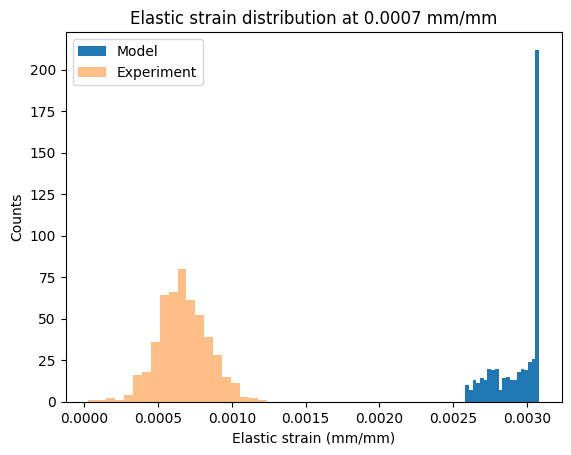

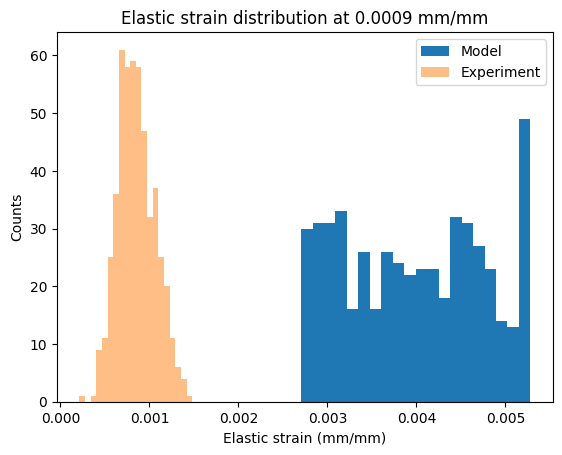

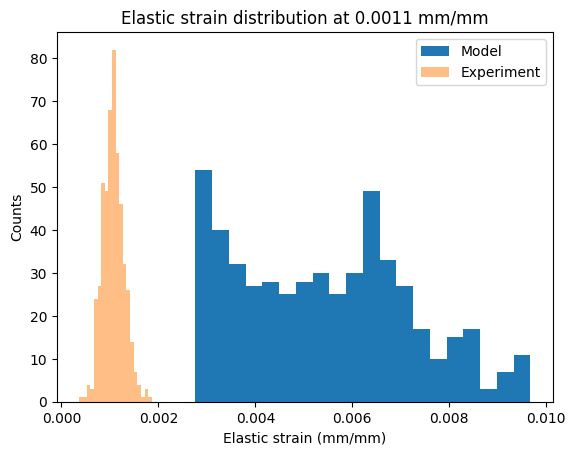

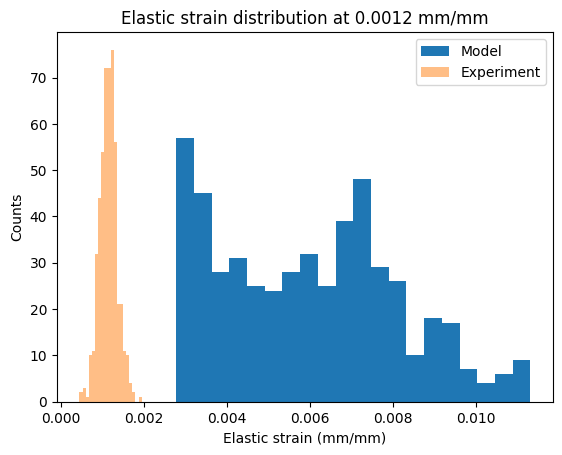

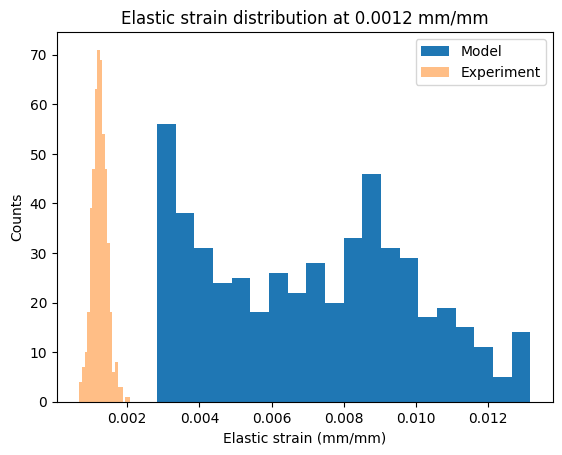

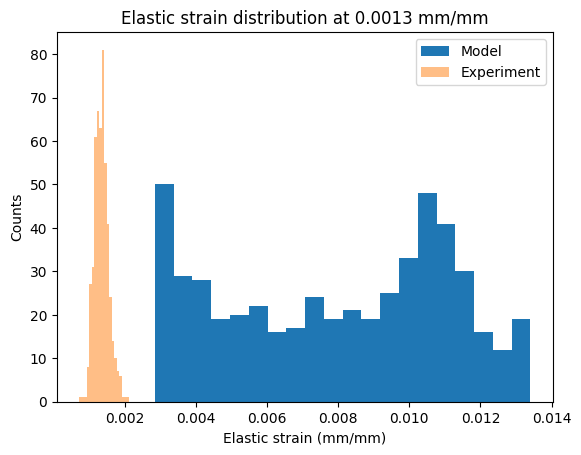

In [ ]:
# Elastic strain without residual
plt.hist(exp_strain[0][:,axial_index].numpy(), bins = 20, alpha = 0.5, label = "Experiment", color = 'tab:orange')
plt.xlabel('Elastic strain (mm/mm)')
plt.ylabel('Counts')
plt.legend(loc='best')
plt.title(f'Elastic strain distribution at 0.0 mm/mm')
for ii,i in enumerate(inds):
    plt.figure()
    model_strain = vars['state/elastic_strain'].torch()[i,:,axial_index].numpy()
    plt.hist(model_strain, bins = 20, label = "Model")
    dexp_strain = exp_strain[ii][:,axial_index].numpy()
    plt.hist(exp_strain[ii][:,axial_index].numpy(), bins = 20, alpha = 0.5, label = "Experiment")
    plt.xlabel('Elastic strain (mm/mm)')
    plt.ylabel('Counts')
    plt.legend(loc='best')
    plt.title(f'Elastic strain distribution at {new_strain[i]:.4f} mm/mm')

In [28]:
stress_hist, state_hist = simulate_stress(optx, return_state=True, initial_strains = exp_strain[0])
vars = tmodel.state_asm.split_by_variable(neml2.Tensor(state_hist, 1))

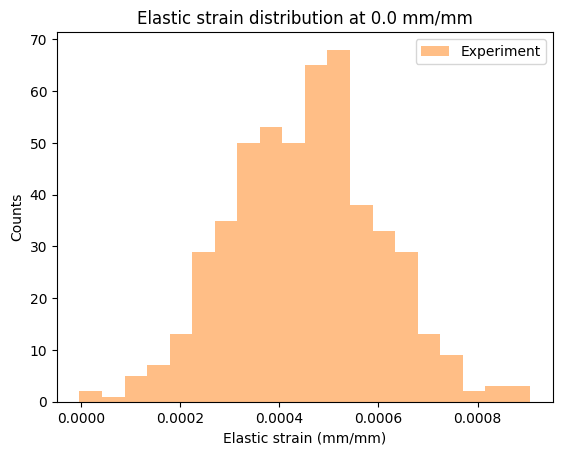

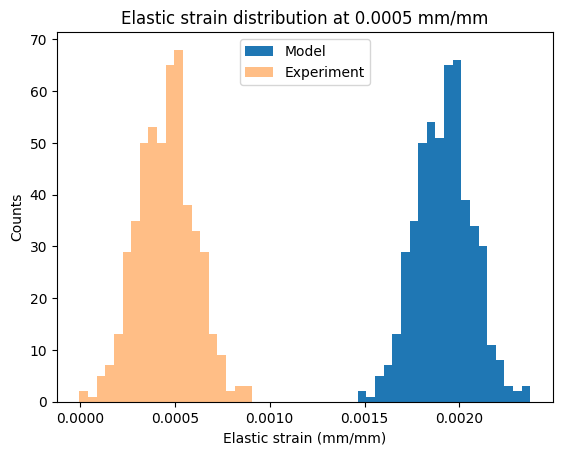

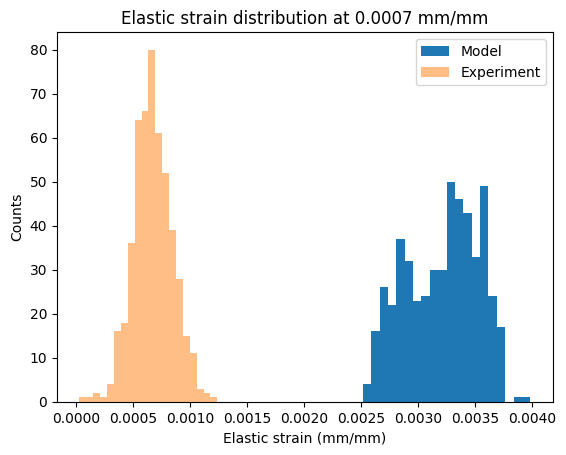

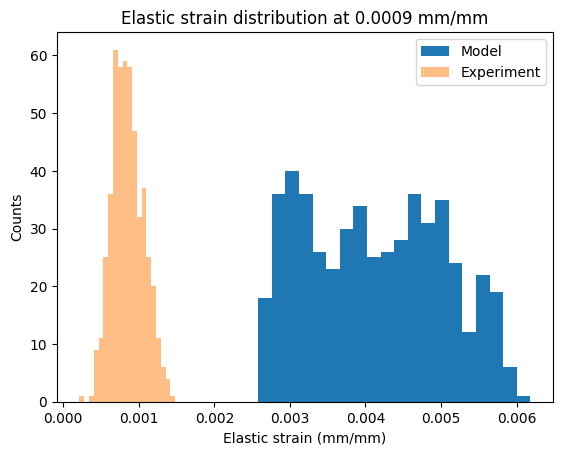

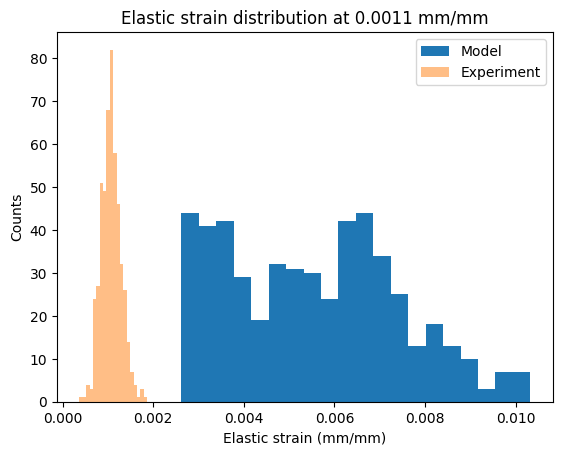

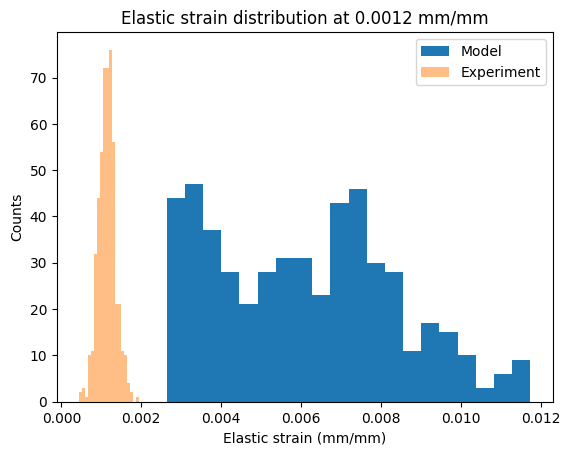

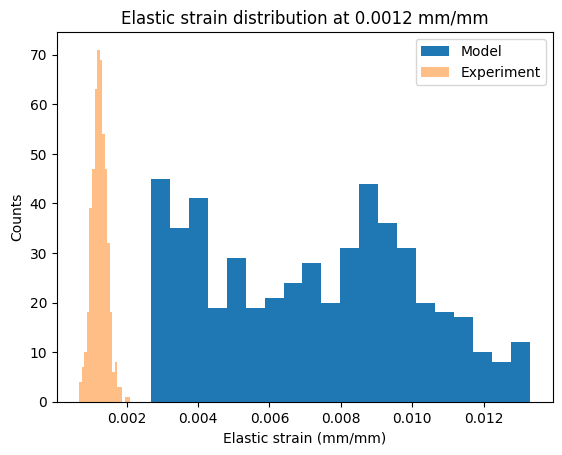

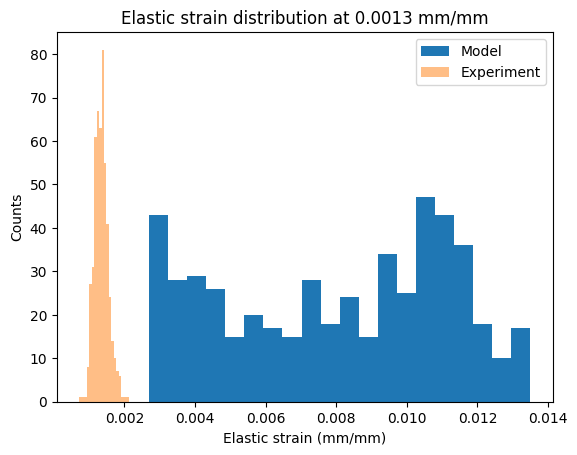

In [34]:
# Elastic strain without residual
plt.hist(
    exp_strain[0][:, axial_index].numpy(),
    bins=20,
    alpha=0.5,
    label="Experiment",
    color="tab:orange",
)
plt.xlabel("Elastic strain (mm/mm)")
plt.ylabel("Counts")
plt.legend(loc="best")
plt.title(f"Elastic strain distribution at 0.0 mm/mm")
for ii, i in enumerate(inds):
    plt.figure()
    model_strain = vars["state/elastic_strain"].torch()[i, :, axial_index].numpy()
    plt.hist(model_strain, bins=20, label="Model")
    dexp_strain = exp_strain[ii][:, axial_index].numpy()
    plt.hist(
        exp_strain[ii][:, axial_index].numpy(), bins=20, alpha=0.5, label="Experiment"
    )
    plt.xlabel("Elastic strain (mm/mm)")
    plt.ylabel("Counts")
    plt.legend(loc="best")
    plt.title(f"Elastic strain distribution at {new_strain[i]:.4f} mm/mm")